


# **Understanding Batch Normalization: A Simple Explanation**

In the realm of deep learning, Batch Normalization (BN) emerges as a crucial technique to enhance training stability and speed. Simply put, it normalizes the input of each layer by adjusting and scaling it. This process aids in combating issues like vanishing or exploding gradients, ultimately leading to more efficient and faster convergence during training.

To demystify the concept, I've crafted a code snippet that illustrates the working of Batch Normalization in a straightforward manner. Take a glance to unravel the simplicity behind this powerful technique.

Happy learning!



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv('/kaggle/input/knn-dataset/knn-data/3.concertriccir2.csv')
df.head()

,7.003345706103683010e-01,-2.470675778972781789e-01,0.000000000000000000e+00
0,-3.950019,2.740080,1.0
1,0.150222,-2.157638,1.0
2,-1.672050,-0.941519,1.0
3,2.560483,-1.846577,1.0
4,-1.724979,3.463930,1.0


In [3]:
column_name = {
    "7.003345706103683010e-01":'X',
    "-2.470675778972781789e-01":'Y',
    "0.000000000000000000e+00" :'class'
}
df = df.rename(columns=column_name)
df.head()

,X,Y,class
0,-3.950019,2.740080,1.0
1,0.150222,-2.157638,1.0
2,-1.672050,-0.941519,1.0
3,2.560483,-1.846577,1.0
4,-1.724979,3.463930,1.0


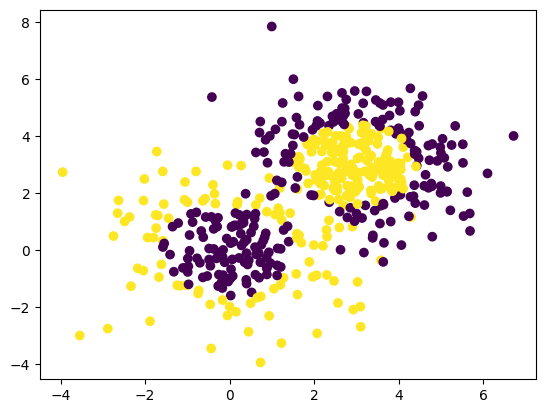

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,BatchNormalization
from keras.utils import plot_model

In [7]:
model = Sequential()

model.add(Dense(3,input_dim=2,activation = 'relu'))
model.add(Dense(2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 3)                 9         
                                                                 
 dense_1 (Dense)             (None, 2)                 8         
                                                                 
 dense_2 (Dense)             (None, 1)                 3         
                                                                 
Total params: 20 (80.00 Byte)
Trainable params: 20 (80.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


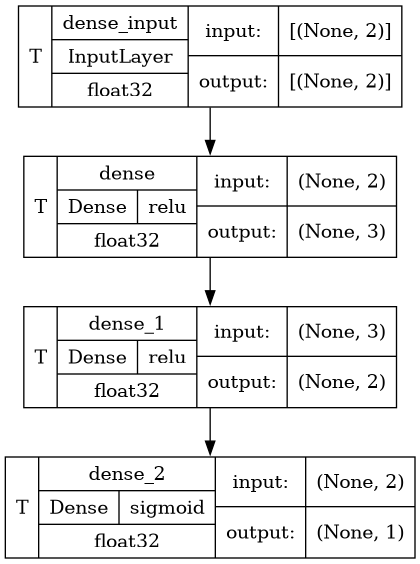

In [8]:
plot_model(model,to_file='plot_model.png', show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    expand_nested=True,
    show_layer_activations=True,
    show_trainable=True)

In [9]:
model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])
history1 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
13/13 [==============================] - 1s 34ms/step - loss: 0.8264 - accuracy: 0.5539 - val_loss: 1.0849 - val_accuracy: 0.5900
Epoch 2/200
13/13 [==============================] - 0s 4ms/step - loss: 0.7921 - accuracy: 0.5789 - val_loss: 1.0027 - val_accuracy: 0.6000
Epoch 3/200
13/13 [==============================] - 0s 5ms/step - loss: 0.7635 - accuracy: 0.5714 - val_loss: 0.9453 - val_accuracy: 0.5700
Epoch 4/200
13/13 [==============================] - 0s 5ms/step - loss: 0.7462 - accuracy: 0.5639 - val_loss: 0.9022 - val_accuracy: 0.5500
Epoch 5/200
13/13 [==============================] - 0s 5ms/step - loss: 0.7340 - accuracy: 0.5589 - val_loss: 0.8692 - val_accuracy: 0.5500
Epoch 6/200
13/13 [==============================] - 0s 4ms/step - loss: 0.7277 - accuracy: 0.5464 - val_loss: 0.8450 - val_accuracy: 0.5100
Epoch 7/200
13/13 [==============================] - 0s 4ms/step - loss: 0.7218 - accuracy: 0.5388 - val_loss: 0.8354 - val_accuracy: 0.5000
Epoch 8/200


In [10]:
model2 = Sequential()

model2.add(Dense(3,input_dim = 2, activation='relu'))
model2.add(BatchNormalization())
model2.add(Dense(2,activation='relu'))
model2.add(BatchNormalization())
model2.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 3)                 9         
                                                                 
 dense_1 (Dense)             (None, 2)                 8         
                                                                 
 dense_2 (Dense)             (None, 1)                 3         
                                                                 
Total params: 20 (80.00 Byte)
Trainable params: 20 (80.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


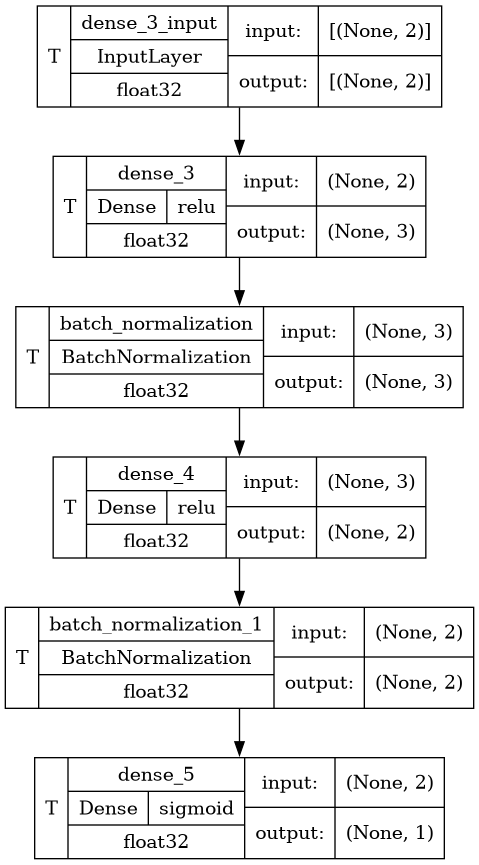

In [11]:
plot_model(model2,to_file='plot_model2.png', show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    expand_nested=True,
    show_layer_activations=True,
    show_trainable=True)

In [12]:
model2.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])
history2 = model2.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
13/13 [==============================] - 1s 17ms/step - loss: 0.7810 - accuracy: 0.5714 - val_loss: 0.7885 - val_accuracy: 0.5700
Epoch 2/200
13/13 [==============================] - 0s 5ms/step - loss: 0.7777 - accuracy: 0.5614 - val_loss: 0.7491 - val_accuracy: 0.5600
Epoch 3/200
13/13 [==============================] - 0s 4ms/step - loss: 0.7529 - accuracy: 0.5915 - val_loss: 0.7238 - val_accuracy: 0.5500
Epoch 4/200
13/13 [==============================] - 0s 6ms/step - loss: 0.7466 - accuracy: 0.6015 - val_loss: 0.7093 - val_accuracy: 0.5200
Epoch 5/200
13/13 [==============================] - 0s 6ms/step - loss: 0.7440 - accuracy: 0.6040 - val_loss: 0.6990 - val_accuracy: 0.4900
Epoch 6/200
13/13 [==============================] - 0s 5ms/step - loss: 0.7345 - accuracy: 0.6090 - val_loss: 0.6923 - val_accuracy: 0.4700
Epoch 7/200
13/13 [==============================] - 0s 4ms/step - loss: 0.7298 - accuracy: 0.6115 - val_loss: 0.6885 - val_accuracy: 0.4700
Epoch 8/200


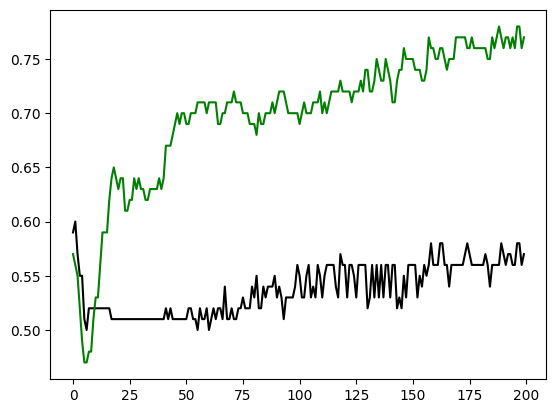

In [13]:
plt.plot(history1.history['val_accuracy'],color='black')
plt.plot(history2.history['val_accuracy'],color='green')


<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Create Better & Beautiful Notebooks : The Tutorial 📚</title>
    <style>
        body {
            font-family: 'Verdana', Cursive;
            background-color: #f0f0f0;
            margin: 0;
            padding: 0;
            display: flex;
            justify-content: center;
            align-items: center;
            height: 100vh;
        }

        .container {
            background-color: #fff;
            border-radius: 10px;
            box-shadow: 0 0 10px rgba(0, 0, 0, 0.1);
            padding: 20px;
            text-align: justify;
            max-width: 800px;
            width: 100%;
        }

        h1 {
            color: #202EF9;
            text-align: center;
            margin-bottom: 20px;
        }

        h2 {
            color: #FE1C0A;
        }

        h3 {
            color: #159364;
        }

        p {
            line-height: 1.5;
        }

        code {
            background-color: #f8f8f8;
            padding: 2px 5px;
            border-radius: 3px;
            font-family: 'Courier New', Courier, monospace;
        }

        .callout {
            background-color: #007bff;
            color: white;
            padding: 10px;
            margin: 10px 0;
            border-radius: 5px;
        }

        .textbox {
            color: white;
            display: fill;
            border-radius: 5px;
            background-color: #5642C5;
            font-size: 110%;
            font-family: 'Verdana', Cursive;
            letter-spacing: 0.5px;
            margin-top: 20px;
        }

        .textbox p {
            padding: 10px;
            color: white;
        }
    </style>
</head>
<body>
    <div class="container">
        <h1>Create Better & Beautiful Notebooks : The Tutorial 📚</h1>

        <p>Strive for Excellence, Not Perfection</p>

        <div class="callout">
            <p>This notebook is created for people who want to make their notebooks look āesthetic and more pleasing to the viewer. We are not going to solve any machine learning problem in this notebook (you can check my other notebooks for ML and EDA). We will only focus on the HTML & Markdown to make your notebooks look prettier and beautiful 🙌🏻.</p>
        </div>

        <h2>By the end of this notebook you will be able to:</h2>
        <ul>
            <li>Beautifully format your notebooks.</li>
            <li>Learn how to use HTML and Markdown in Kaggle notebooks.</li>
            <li>Learn some good quotes.</li>
        </ul>

        <div class="callout">
            <p>📌 Please keep in mind that, I am a beginner and on my learning journey as most of you. I just want to share something that will be useful for many Kagglers working hard on their notebooks. If you find this notebook useful in any way, please upvote it so that it can reach a bigger audience. You can share it with your fellow Kagglers.</p>
        </div>

        <div class="callout">
            <p>💬 Finally, I would like to take this opportunity to remind everyone to be kind, just and mindful 😃</p>
        </div>

        <h2>1. Simple Markdown 🎖</h2>
        <h3>1.1 Making texts italic</h3>
        <!-- Add more sections as needed -->

        <div class="textbox">
            <p>All that is gold does not glitter,<br>Not all those who wander are lost;<br>The old that is strong does not wither,<br>Deep roots are not reached by the frost.</p>
        </div>
    </div>
</body>
</html>
